**Control Bonds**

In [6]:
import sys
import os
import pandas as pd

_HERE = os.getcwd()
_ROOT = os.path.dirname(_HERE)
sys.path.insert(0, _ROOT)
sys.path.insert(0, _HERE)

DATABASE_DIR = os.path.join(_ROOT, 'Database')

bonds = pd.read_parquet(os.path.join(DATABASE_DIR, 'bonds.parquet'))

dates = bonds.index.get_level_values('Date')
print(f'Date range: {dates.min().date()} to {dates.max().date()}')

nan_mask = bonds.isna().any(axis=1)
print(f'Rows with at least one NaN: {nan_mask.sum()} / {len(bonds)}')

nan_by_ticker = (
    bonds[nan_mask]
    .index.to_frame(index=False)
    .groupby('Ticker')['Date']
    .agg(count='count', first='min', last='max')
)
print('\nNaN occurrences by ticker:')
print(nan_by_ticker)

bonds

Date range: 2000-01-03 to 2026-07-30
Rows with at least one NaN: 0 / 86385

NaN occurrences by ticker:
Empty DataFrame
Columns: [count, first, last]
Index: []


Close    High        Low    Open    Volume  Yield  \
Date       Ticker                                                          
2000-01-03 ^FVX     0.000000   6.473   6.411000   6.411       0.0  6.457   
           ^IRX     0.000000   5.300   5.230000   5.230       0.0  5.270   
           ^TNX     0.000000   6.603   6.498000   6.498       0.0  6.548   
           ^TYX     0.000000   6.598   6.537000   6.537       0.0  6.598   
2000-01-04 ^FVX     0.000000   6.450   6.388000   6.434       0.0  6.396   
...                      ...     ...        ...     ...       ...    ...   
2026-07-30 TMV     42.119999  42.520  41.939999  42.090  797500.0  0.000   
           ^FVX     0.000000   4.403   4.359000   4.389       0.0  4.375   
           ^IRX     0.000000   3.675   3.647000   3.668       0.0  3.675   
           ^TNX     0.000000   4.686   4.651000   4.669       0.0  4.663   
           ^TYX     0.000000   5.228   5.192000   5.199       0.0  5.208   

                                                              Name  
Date       Ticker                                                   
2000-01-03 ^FVX                    CBOE 5-Year Treasury Note Yield  
           ^IRX                   CBOE 13-Week Treasury Bill Yield  
           ^TNX                   CBOE 10-Year Treasury Note Yield  
           ^TYX                   CBOE 30-Year Treasury Bond Yield  
2000-01-04 ^FVX                    CBOE 5-Year Treasury Note Yield  
...                                                            ...  
2026-07-30 TMV     Direxion Daily 20+ Year Treasury Bear 3X Shares  
           ^FVX                    CBOE 5-Year Treasury Note Yield  
           ^IRX                   CBOE 13-Week Treasury Bill Yield  
           ^TNX                   CBOE 10-Year Treasury Note Yield  
           ^TYX                   CBOE 30-Year Treasury Bond Yield  

[86385 rows x 7 columns]

**Visualize Bonds**

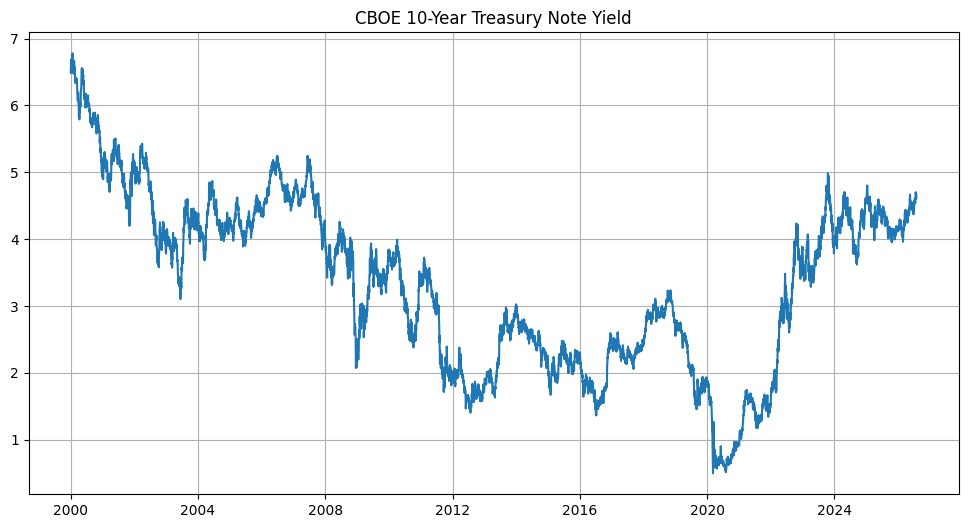

In [13]:
import matplotlib.pyplot as plt

df = pd.read_parquet(os.path.join(DATABASE_DIR, 'bonds.parquet'))

ticker = '^TNX'
data  = 'Yield'         # Yield for Indices, Close for ETFs

name = df["Name"].xs(ticker, level="Ticker").iloc[0]

plt.figure(figsize=(12,6))

plt.plot(df[data].xs(ticker, level="Ticker"))
plt.title(name)
plt.grid(True)

plt.show()

**Control Commodities**

In [19]:
import sys
import os
import pandas as pd

_HERE = os.getcwd()
_ROOT = os.path.dirname(_HERE)
sys.path.insert(0, _ROOT)
sys.path.insert(0, _HERE)

DATABASE_DIR = os.path.join(_ROOT, 'Database')

commodities = pd.read_parquet(os.path.join(DATABASE_DIR, 'commodities.parquet'))

dates = commodities.index.get_level_values('Date')
print(f'Date range: {dates.min().date()} to {dates.max().date()}')

nan_mask = commodities.isna().any(axis=1)
print(f'Rows with at least one NaN: {nan_mask.sum()} / {len(commodities)}')

nan_by_ticker = (
    commodities[nan_mask]
    .index.to_frame(index=False)
    .groupby('Ticker')['Date']
    .agg(count='count', first='min', last='max')
)
print('\nNaN occurrences by ticker:')
print(nan_by_ticker)

commodities

Date range: 2000-01-03 to 2026-07-30
Rows with at least one NaN: 0 / 483730

NaN occurrences by ticker:
Empty DataFrame
Columns: [count, first, last]
Index: []


Open         High          Low        Close  \
Date       Ticker                                                       
2000-01-03 AA        70.513277    70.991152    68.283188    68.761063   
           ADM        5.929679     5.960563     5.867912     5.929679   
           ANDE       1.693971     1.733673     1.693971     1.733673   
           BHP        3.068886     3.068886     2.989456     2.989456   
           CC=F     840.000000   846.000000   820.000000   830.000000   
...                        ...          ...          ...          ...   
2026-07-30 ZM=F     320.200012   321.500000   312.700012   315.299988   
           ZO=F     332.250000   332.250000   332.250000   332.250000   
           ZR=F      13.790000    13.900000    13.790000    13.880000   
           ZS=F    1213.500000  1217.250000  1175.500000  1178.000000   
           ZW=F     666.750000   672.250000   658.250000   660.750000   

                      Volume                            Name  
Date       Ticker                                             
2000-01-03 AA      1291386.0               Alcoa Corporation  
           ADM      984753.0  Archer-Daniels-Midland Company  
           ANDE       2400.0             The Andersons, Inc.  
           BHP       68140.0               BHP Group Limited  
           CC=F       2426.0                   Cocoa Futures  
...                      ...                             ...  
2026-07-30 ZM=F      28476.0            Soybean Meal Futures  
           ZO=F          3.0                     Oat Futures  
           ZR=F         54.0              Rough Rice Futures  
           ZS=F      28402.0                 Soybean Futures  
           ZW=F      57585.0                   Wheat Futures  

[483730 rows x 6 columns]

**Visualize Commodities**

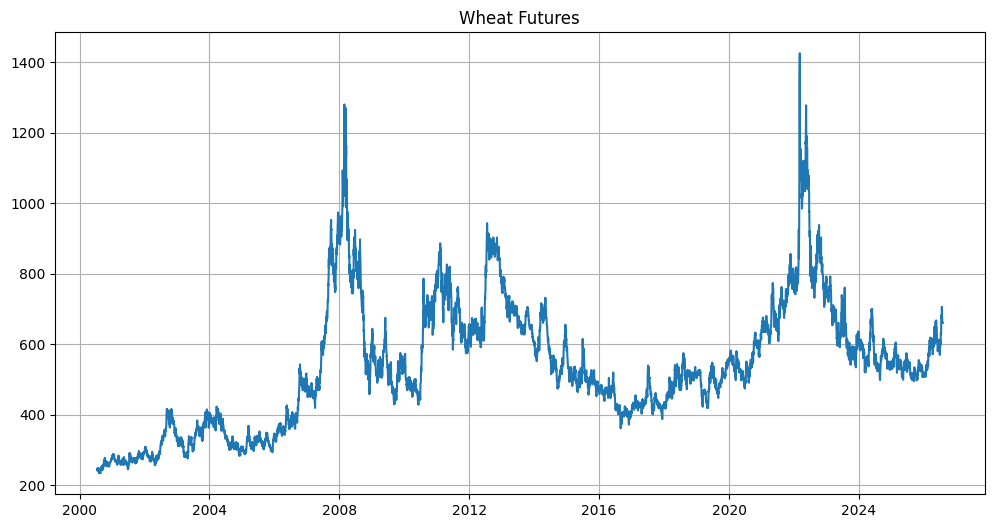

In [20]:
import matplotlib.pyplot as plt

df = pd.read_parquet(os.path.join(DATABASE_DIR, 'commodities.parquet'))

ticker = 'ZW=F'
data  = 'Close'         # Yield for Indices, Close for ETFs

name = df["Name"].xs(ticker, level="Ticker").iloc[0]

plt.figure(figsize=(12,6))

plt.plot(df[data].xs(ticker, level="Ticker"))
plt.title(name)
plt.grid(True)

plt.show()

**Control Crpypto**

In [21]:
import sys
import os
import pandas as pd

_HERE = os.getcwd()
_ROOT = os.path.dirname(_HERE)
sys.path.insert(0, _ROOT)
sys.path.insert(0, _HERE)

DATABASE_DIR = os.path.join(_ROOT, 'Database')

crypto = pd.read_parquet(os.path.join(DATABASE_DIR, 'crypto.parquet'))

dates = crypto.index.get_level_values('Date')
print(f'Date range: {dates.min().date()} to {dates.max().date()}')

nan_mask = crypto.isna().any(axis=1)
print(f'Rows with at least one NaN: {nan_mask.sum()} / {len(crypto)}')

nan_by_ticker = (
    crypto[nan_mask]
    .index.to_frame(index=False)
    .groupby('Ticker')['Date']
    .agg(count='count', first='min', last='max')
)
print('\nNaN occurrences by ticker:')
print(nan_by_ticker)

crypto

Date range: 2014-09-17 to 2026-07-29
Rows with at least one NaN: 0 / 10704

NaN occurrences by ticker:
Empty DataFrame
Columns: [count, first, last]
Index: []


Open          High           Low         Close  \
Date       Ticker                                                             
2014-09-17 BTC-USD     465.864014    468.174011    452.421997    457.334015   
2014-09-18 BTC-USD     456.859985    456.859985    413.104004    424.440002   
2014-09-19 BTC-USD     424.102997    427.834991    384.532013    394.795990   
2014-09-20 BTC-USD     394.673004    423.295990    389.882996    408.903992   
2014-09-21 BTC-USD     408.084991    412.425995    393.181000    398.821014   
...                           ...           ...           ...           ...   
2026-07-28 ETH-USD    1890.634521   1926.504028   1856.341553   1919.948486   
           USDT-USD      0.999151      1.000120      0.998582      0.998746   
2026-07-29 BTC-USD   63871.394531  64638.695312  63206.210938  63908.167969   
           ETH-USD    1919.991577   1929.900879   1873.619263   1908.519043   
           USDT-USD      0.998775      0.999676      0.998360      0.998779   

                           Volume      Name  
Date       Ticker                            
2014-09-17 BTC-USD   2.105680e+07   Bitcoin  
2014-09-18 BTC-USD   3.448320e+07   Bitcoin  
2014-09-19 BTC-USD   3.791970e+07   Bitcoin  
2014-09-20 BTC-USD   3.686360e+07   Bitcoin  
2014-09-21 BTC-USD   2.658010e+07   Bitcoin  
...                           ...       ...  
2026-07-28 ETH-USD   1.147607e+10  Ethereum  
           USDT-USD  5.326199e+10    Tether  
2026-07-29 BTC-USD   2.861117e+10   Bitcoin  
           ETH-USD   1.200343e+10  Ethereum  
           USDT-USD  5.638132e+10    Tether  

[10704 rows x 6 columns]

**Visualize Crypto**

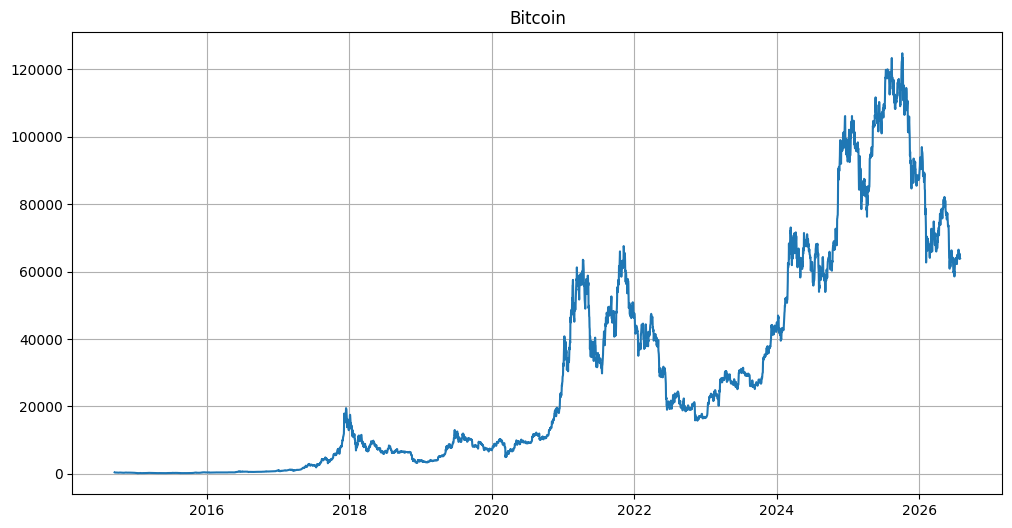

In [22]:
import matplotlib.pyplot as plt

df = pd.read_parquet(os.path.join(DATABASE_DIR, 'crypto.parquet'))

ticker = 'BTC-USD'
data  = 'Close'         # Yield for Indices, Close for ETFs

name = df["Name"].xs(ticker, level="Ticker").iloc[0]

plt.figure(figsize=(12,6))

plt.plot(df[data].xs(ticker, level="Ticker"))
plt.title(name)
plt.grid(True)

plt.show()

**Control Forex**

In [23]:
import sys
import os
import pandas as pd

_HERE = os.getcwd()
_ROOT = os.path.dirname(_HERE)
sys.path.insert(0, _ROOT)
sys.path.insert(0, _HERE)

DATABASE_DIR = os.path.join(_ROOT, 'Database')

forex = pd.read_parquet(os.path.join(DATABASE_DIR, 'forex.parquet'))

dates = forex.index.get_level_values('Date')
print(f'Date range: {dates.min().date()} to {dates.max().date()}')

nan_mask = forex.isna().any(axis=1)
print(f'Rows with at least one NaN: {nan_mask.sum()} / {len(forex)}')

nan_by_ticker = (
    forex[nan_mask]
    .index.to_frame(index=False)
    .groupby('Ticker')['Date']
    .agg(count='count', first='min', last='max')
)
print('\nNaN occurrences by ticker:')
print(nan_by_ticker)

forex

Date range: 2000-01-03 to 2026-07-30
Rows with at least one NaN: 0 / 414013

NaN occurrences by ticker:
Empty DataFrame
Columns: [count, first, last]
Index: []


Open        High         Low       Close  \
Date       Ticker                                                     
2000-01-03 DX-Y.NYB  101.669998  101.830002  100.190002  100.220001   
           EURGBP=X    0.623900    0.629000    0.620300    0.625400   
           EURSEK=X    8.562500    8.630000    8.536700    8.569100   
           USDJPY=X  102.070000  103.330002  101.309998  101.690002   
2000-01-04 DX-Y.NYB  100.550003  100.860001  100.010002  100.410004   
...                         ...         ...         ...         ...   
2026-07-30 USDTHB=X   33.470001   33.683998   33.341000   33.459999   
           USDTRY=X   47.399200   47.418499   47.335899   47.369888   
           USDTWD=X   32.348900   32.551998   32.320000   32.348900   
           USDZAR=X   16.648750   16.707399   16.455700   16.660431   
           UUP        28.360001   28.360001   28.120001   28.139999   

                        Volume                                     Name  
Date       Ticker                                                        
2000-01-03 DX-Y.NYB        0.0                ICE US Dollar Index (DXY)  
           EURGBP=X        0.0                     Euro / British Pound  
           EURSEK=X        0.0                     Euro / Swedish Krona  
           USDJPY=X        0.0                 US Dollar / Japanese Yen  
2000-01-04 DX-Y.NYB        0.0                ICE US Dollar Index (DXY)  
...                        ...                                      ...  
2026-07-30 USDTHB=X        0.0                    US Dollar / Thai Baht  
           USDTRY=X        0.0                 US Dollar / Turkish Lira  
           USDTWD=X        0.0            US Dollar / New Taiwan Dollar  
           USDZAR=X        0.0           US Dollar / South African Rand  
           UUP       4809000.0  Invesco DB US Dollar Index Bullish Fund  

[414013 rows x 6 columns]

**Visualize Forex**

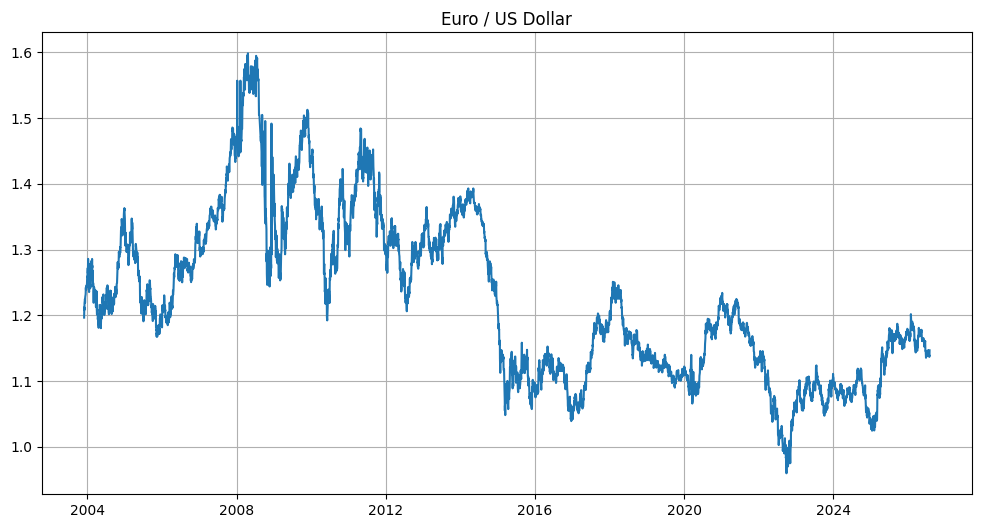

In [24]:
import matplotlib.pyplot as plt

df = pd.read_parquet(os.path.join(DATABASE_DIR, 'forex.parquet'))

ticker = 'EURUSD=X'
data  = 'Close'         # Yield for Indices, Close for ETFs

name = df["Name"].xs(ticker, level="Ticker").iloc[0]

plt.figure(figsize=(12,6))

plt.plot(df[data].xs(ticker, level="Ticker"))
plt.title(name)
plt.grid(True)

plt.show()